In [1]:
!nvidia-smi

Thu May 14 20:46:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%%writefile 3_reduction.cu

Writing 3_reduction.cu


In [8]:
%%writefile 3_reduction.cu
// Matrix Multiplication using CUDA (Global and Shared Memory)
// Compile: nvcc 4_matrix_mul.cu -o 4_matrix_mul
// Run:     ./4_matrix_mul

#include <iostream>
#include <fstream>
#include <cstdlib>
#include <ctime>
#include <cuda_runtime.h>
using namespace std;

#define TILE 16

#define CHECK(c) { \
    cudaError_t e = (c); \
    if (e != cudaSuccess) { \
        cout << "CUDA error: " << cudaGetErrorString(e) << endl; \
        exit(1); \
    } \
}

__global__ void matMulGlobal(float *A, float *B, float *C, int n) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < n && col < n) {
        float sum = 0;
        for (int k = 0; k < n; k++)
            sum += A[row * n + k] * B[k * n + col];
        C[row * n + col] = sum;
    }
}

__global__ void matMulShared(float *A, float *B, float *C, int n) {
    __shared__ float tA[TILE][TILE];
    __shared__ float tB[TILE][TILE];
    int row = blockIdx.y * TILE + threadIdx.y;
    int col = blockIdx.x * TILE + threadIdx.x;
    float sum = 0;
    for (int t = 0; t < (n + TILE - 1) / TILE; t++) {
        if (row < n && t * TILE + threadIdx.x < n)
            tA[threadIdx.y][threadIdx.x] = A[row * n + t * TILE + threadIdx.x];
        else
            tA[threadIdx.y][threadIdx.x] = 0;
        if (col < n && t * TILE + threadIdx.y < n)
            tB[threadIdx.y][threadIdx.x] = B[(t * TILE + threadIdx.y) * n + col];
        else
            tB[threadIdx.y][threadIdx.x] = 0;
        __syncthreads();
        for (int k = 0; k < TILE; k++)
            sum += tA[threadIdx.y][k] * tB[k][threadIdx.x];
        __syncthreads();
    }
    if (row < n && col < n)
        C[row * n + col] = sum;
}

void cpuMatMul(float *A, float *B, float *C, int n) {
    for (int i = 0; i < n; i++) {
        for (int j = 0; j < n; j++) {
            float sum = 0;
            for (int k = 0; k < n; k++)
                sum += A[i * n + k] * B[k * n + j];
            C[i * n + j] = sum;
        }
    }
}

int main() {
    cout << "Neeti Kurulkar BE A 41038" << endl << endl;

    int smCount;
    cudaDeviceGetAttribute(&smCount, cudaDevAttrMultiProcessorCount, 0);

    float *tmp;
    cudaMalloc(&tmp, sizeof(float));
    cudaDeviceSynchronize();
    cudaFree(tmp);

    int mat_sizes[] = {64, 128, 256, 512};
    int num_sizes = 4;

    ofstream csv("4_matrix_mul.csv");
    csv << "size,seq_time,par_global,par_shared,speedup_global,speedup_shared,efficiency\n";

    cout << "N\tSeq(s)\t\tGlobal(s)\tShared(s)\tSp(Gl)\t\tSp(Sh)\t\tEfficiency" << endl;

    for (int t = 0; t < num_sizes; t++) {
        int n = mat_sizes[t];
        int tot = n * n;

        float *h_A = new float[tot];
        float *h_B = new float[tot];
        float *h_C = new float[tot]();
        for (int i = 0; i < tot; i++) {
            h_A[i] = rand() % 10;
            h_B[i] = rand() % 10;
        }

        double cpu_start = (double)clock() / CLOCKS_PER_SEC;
        cpuMatMul(h_A, h_B, h_C, n);
        double seq_time = (double)clock() / CLOCKS_PER_SEC - cpu_start;

        float *d_A, *d_B, *d_C;
        CHECK(cudaMalloc(&d_A, tot * sizeof(float)));
        CHECK(cudaMalloc(&d_B, tot * sizeof(float)));
        CHECK(cudaMalloc(&d_C, tot * sizeof(float)));
        CHECK(cudaMemcpy(d_A, h_A, tot * sizeof(float), cudaMemcpyHostToDevice));
        CHECK(cudaMemcpy(d_B, h_B, tot * sizeof(float), cudaMemcpyHostToDevice));

        dim3 threads(TILE, TILE);
        dim3 blocks((n + TILE - 1) / TILE, (n + TILE - 1) / TILE);
        cudaEvent_t e1, e2;
        float ms;
        cudaEventCreate(&e1);
        cudaEventCreate(&e2);

        cudaMemset(d_C, 0, tot * sizeof(float));
        cudaEventRecord(e1);
        matMulGlobal<<<blocks, threads>>>(d_A, d_B, d_C, n);
        cudaEventRecord(e2);
        cudaEventSynchronize(e2);
        cudaEventElapsedTime(&ms, e1, e2);
        double par_global = ms / 1000.0;

        cudaMemset(d_C, 0, tot * sizeof(float));
        cudaEventRecord(e1);
        matMulShared<<<blocks, threads>>>(d_A, d_B, d_C, n);
        cudaEventRecord(e2);
        cudaEventSynchronize(e2);
        cudaEventElapsedTime(&ms, e1, e2);
        double par_shared = ms / 1000.0;

        double sp_global  = seq_time / par_global;
        double sp_shared  = seq_time / par_shared;
        double efficiency = sp_shared / smCount;

        cout << n << "\t" << seq_time << "\t\t" << par_global << "\t\t" << par_shared << "\t\t"
             << sp_global << "\t\t" << sp_shared << "\t\t" << efficiency << endl;

        csv << n << "," << seq_time << "," << par_global << "," << par_shared << ","
            << sp_global << "," << sp_shared << "," << efficiency << "\n";

        cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
        cudaEventDestroy(e1); cudaEventDestroy(e2);
        delete[] h_A; delete[] h_B; delete[] h_C;
    }

    csv.close();
    cout << "\nSaved to 4_matrix_mul.csv" << endl;
    return 0;
}


Overwriting 3_reduction.cu


In [9]:
!nvcc 3_reduction.cu -o 3_reduction

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [10]:
!./3_reduction

Neeti Kurulkar BE A 41038

N	Seq(s)		Global(s)	Shared(s)	Sp(Gl)		Sp(Sh)		Efficiency
64	0.001275		0.0323912		2.016e-05		0.0393626		63.244		1.5811
128	0.006594		2.2528e-05		1.632e-05		292.702		404.044		10.1011
256	0.054937		0.000102592		6.9824e-05		535.49		786.792		19.6698
512	0.655649		0.00073712		0.000473408		889.474		1384.96		34.6239

Saved to 4_matrix_mul.csv


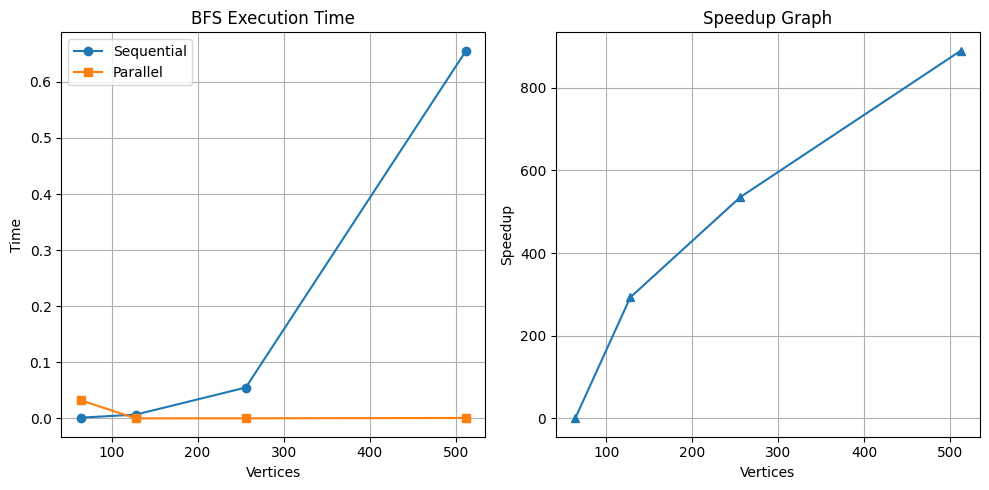

Graph saved as bfs_graph.png


In [13]:
import csv
import matplotlib.pyplot as plt

# Lists
sizes = []
seq = []
par = []
speedup = []

# Read CSV file
with open("4_matrix_mul.csv", "r") as file:

    reader = csv.DictReader(file)

    for row in reader:

        sizes.append(int(row["size"]))
        seq.append(float(row["seq_time"]))
        par.append(float(row["par_global"]))
        speedup.append(float(row["speedup_global"]))

# Create graphs
plt.figure(figsize=(10,5))

# Sequential and Parallel Time
plt.subplot(1,2,1)

plt.plot(sizes, seq, marker='o', label="Sequential")
plt.plot(sizes, par, marker='s', label="Parallel")

plt.xlabel("Vertices")
plt.ylabel("Time")
plt.title("BFS Execution Time")

plt.legend()
plt.grid(True)

# Speedup Graph
plt.subplot(1,2,2)

plt.plot(sizes, speedup, marker='^')

plt.xlabel("Vertices")

plt.ylabel("Speedup")

plt.title("Speedup Graph")

plt.grid(True)

# Save graph
plt.tight_layout()

plt.savefig("bfs_graph.png")

plt.show()

print("Graph saved as bfs_graph.png")